In [1]:
from run_simulation import run_simulation, run_multiple_simulations, print_statistics
import numpy as np

# Run the simulation many times for this scenario and aggregate results
num_permits = 6410
n_runs = 20
base_seed = 42

print(f"Running {n_runs} simulations with {num_permits} permits each...")

scenario = {
    "name": "standard_custom_non_like",
    "sequential": "standard",
    "pct_pre_approved": 0,
    "pct_custom": 1,
    "pct_self_cert": 0,
    "pct_like_for_like": 0,
}

results = run_multiple_simulations(
    n_runs=n_runs,
    num_permits=num_permits,
    inter_arrival_time=0,
    base_seed=base_seed,
    scenario_params_list=[scenario],
    collect_permits=True,
)

# Aggregate permits across runs so visualizations reflect overall behavior
all_permits = [p for r in results for p in r["permits"]]

# Summarize overall behavior across runs using run-level stats
mean_of_means = np.mean([r["stats"]["average_total_time"]["mean"] for r in results])
mean_of_medians = np.mean([r["stats"]["average_total_time"]["median"] for r in results])
print(f"Across {n_runs} runs: mean of means = {mean_of_means:.2f} days; mean of medians = {mean_of_medians:.2f} days")

# Also show detailed statistics for the first run as a concrete example
example_stats = results[0]["stats"]
print_statistics(example_stats)

Running 20 simulations with 6410 permits each...
Across 20 runs: mean of means = 377.89 days; mean of medians = 368.24 days

SIMULATION STATISTICS

Total Completed Permits: 6410
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   :    0 ( 0.00%)
  CUSTOM_NON_LIKE               : 6410 (100.00%)
  PRE_APPROVED_LIKE             :    0 ( 0.00%)
  PRE_APPROVED_NON_LIKE         :    0 ( 0.00%)
  SELF_CERT_LIKE                :    0 ( 0.00%)
  SELF_CERT_NON_LIKE            :    0 ( 0.00%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     378.19 days
  Median:   367.51 days
  Std Dev:  123.86 days
  Min:      121.78 days
  Max:     1543.18 days

---------

In [2]:
# Optional: Access individual permit data
print(f"\nFirst 5 completed permits:")
for permit in all_permits[:5]:
    total_time = permit.ready_for_construction - permit.created_at if permit.ready_for_construction else None
    print(f"  Permit {permit.permit_id} ({permit.segment.name}): "
          f"{total_time:.2f} days total, "
          f"{permit.public_works_rechecks} re-checks")



First 5 completed permits:
  Permit 1526 (CUSTOM_NON_LIKE): 121.78 days total, 0 re-checks
  Permit 435 (CUSTOM_NON_LIKE): 128.35 days total, 1 re-checks
  Permit 383 (CUSTOM_NON_LIKE): 128.42 days total, 0 re-checks
  Permit 571 (CUSTOM_NON_LIKE): 130.51 days total, 1 re-checks
  Permit 526 (CUSTOM_NON_LIKE): 138.36 days total, 0 re-checks


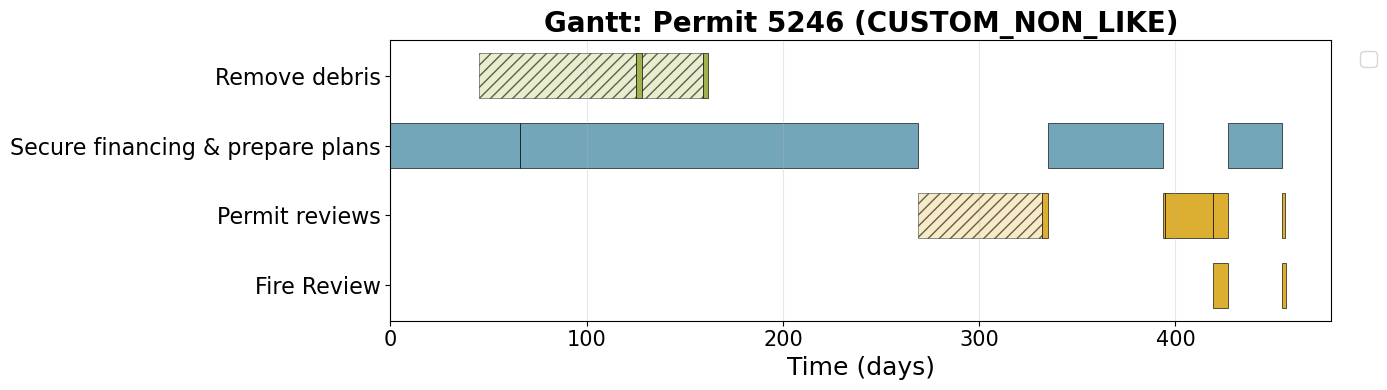

In [3]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_one_random_permit_segment
import matplotlib.pyplot as plt

fig, ax = plot_gantt_one_random_permit_segment(
    results[0]["permits"],
    segment_value=4,
    random_seed=100,
    figsize=(14, 4),
)
if fig:
    plt.show()

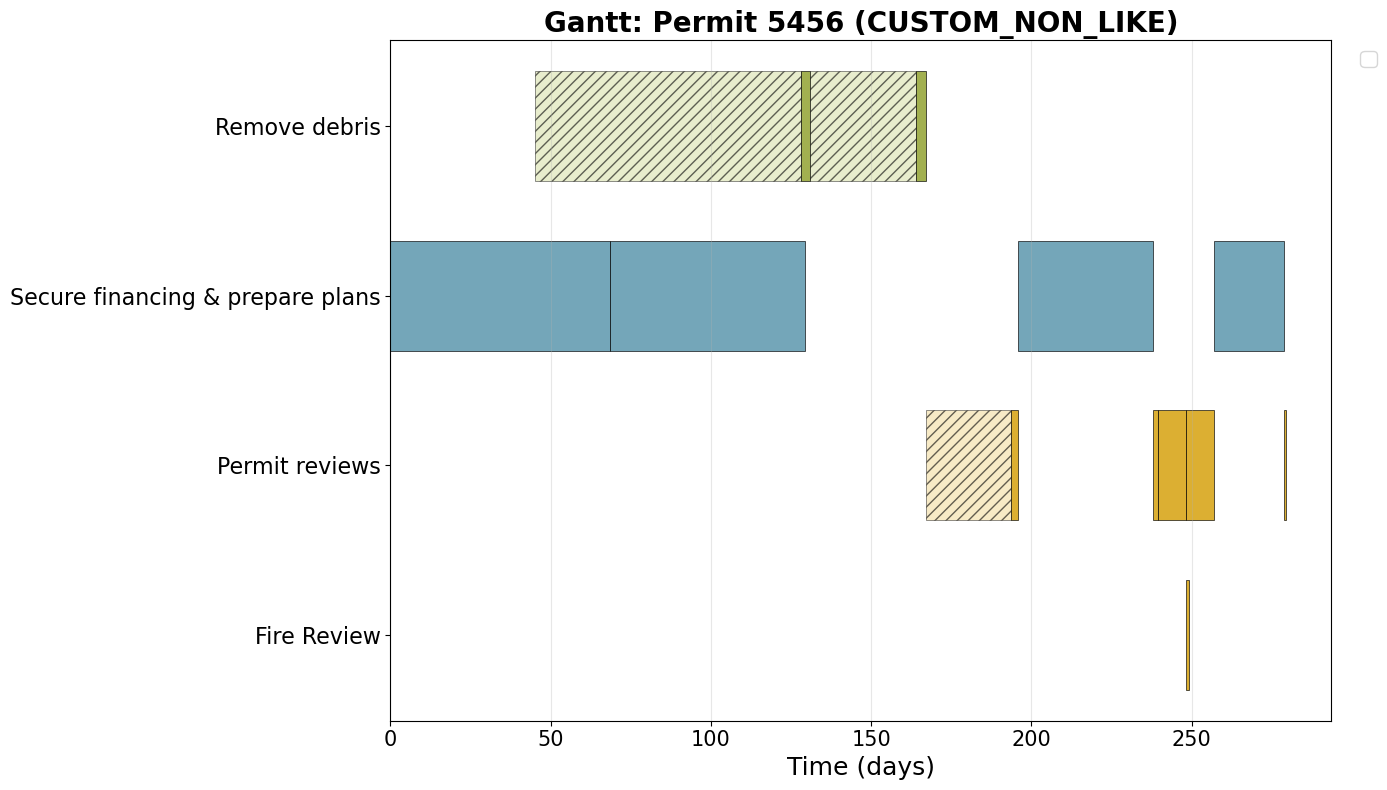

In [4]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_single_permit
import matplotlib.pyplot as plt

fig, ax = plot_gantt_single_permit(
    results[0]["permits"][1460],
    figsize=(14, 8), 
)
if fig:
    plt.show()

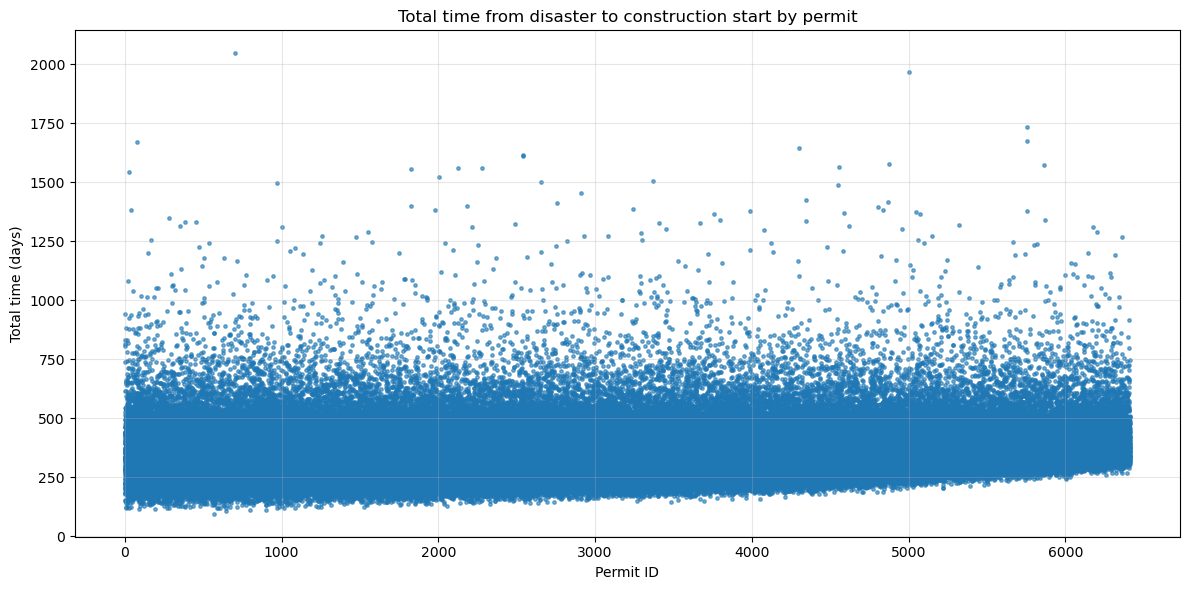

In [5]:
# Plot permit number (ID) vs total time to construction
import matplotlib.pyplot as plt

permit_ids = []
total_times = []

for p in all_permits:
    if p.ready_for_construction is not None and p.created_at is not None:
        permit_ids.append(p.permit_id)
        total_times.append(p.ready_for_construction - p.created_at)

plt.figure(figsize=(12, 6))
plt.scatter(permit_ids, total_times, s=6, alpha=0.6)
plt.xlabel("Permit ID")
plt.ylabel("Total time (days)")
plt.title("Total time from disaster to construction start by permit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

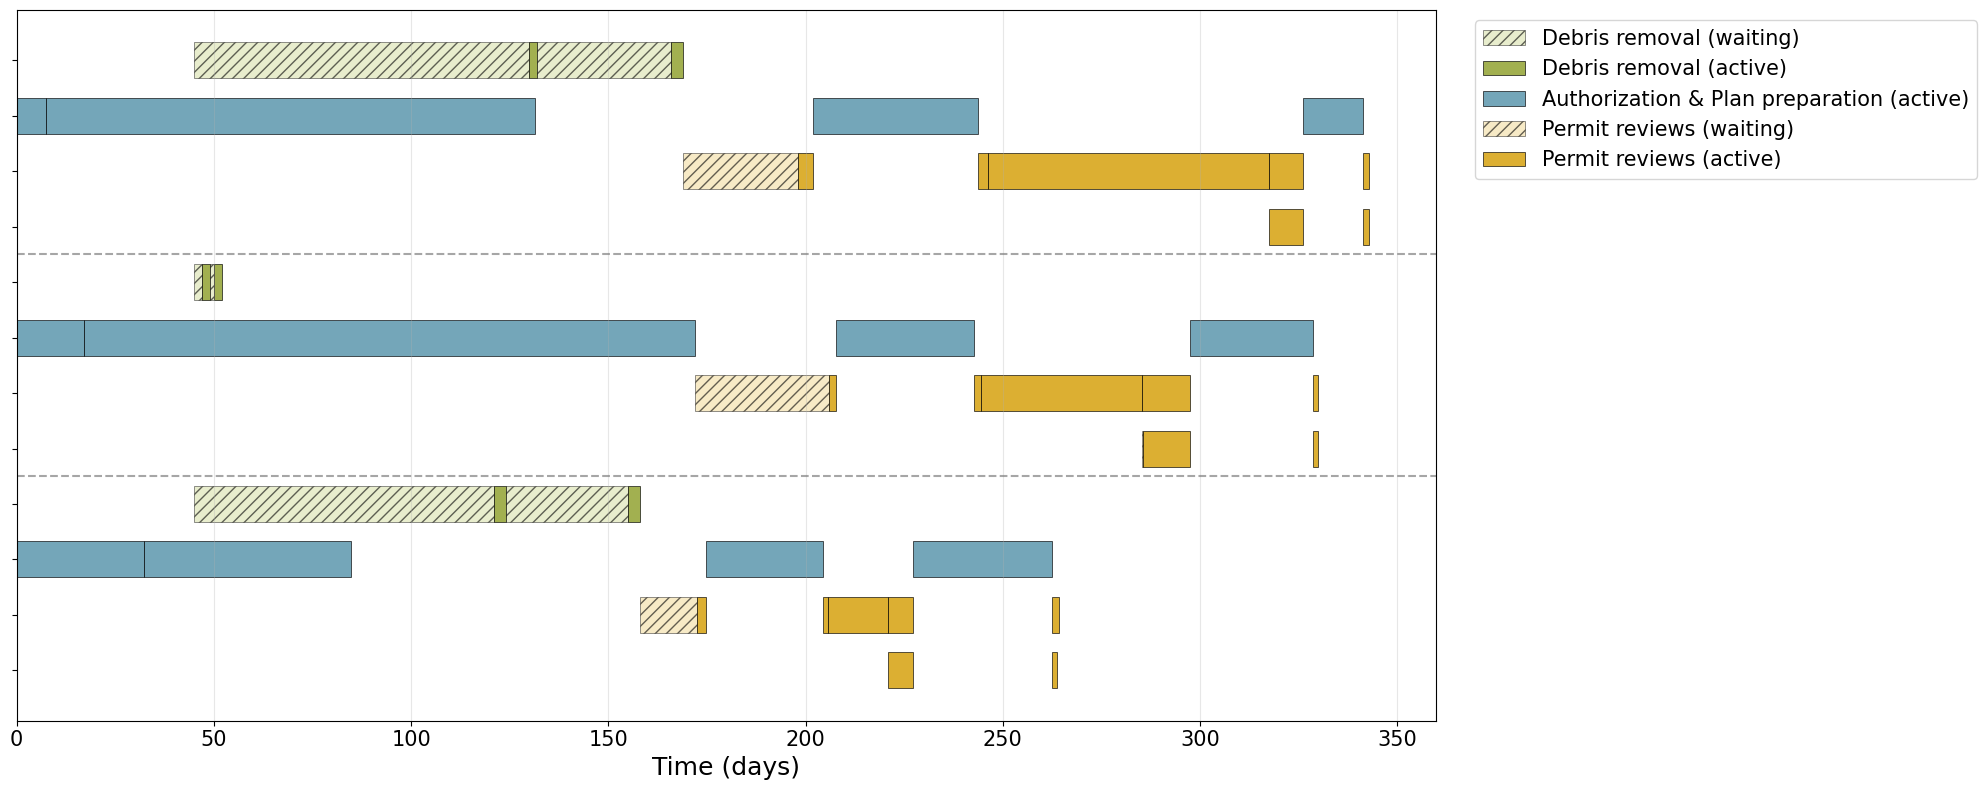

In [6]:
# Gantt chart for 3 random permits
from visualize_permits import plot_gantt_three_random_permits
import matplotlib.pyplot as plt

fig, ax = plot_gantt_three_random_permits(
    results[0]["permits"],
    random_seed=36,
    figsize=(20, 8),
)
if fig:
    plt.show()

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Average Total Waiting vs Service Time by Process Step'}, xlabel='Process Step', ylabel='Average Time (days)'>)

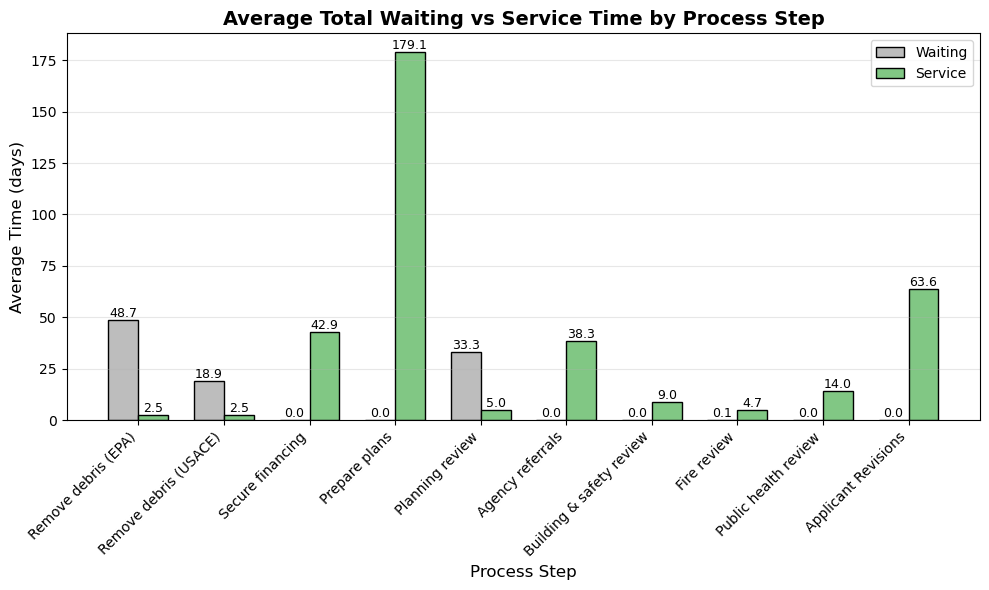

In [7]:
# Visualize the time each permit spends in each stage
from visualize_permits import plot_average_waiting_and_service_by_step


# Visualize aggregate time spent in each process stage across all runs
label_map = {
    "EPA Debris": "Remove debris (EPA)",
    "USACE Debris": "Remove debris (USACE)",
    "Authorization": "Secure financing",
    "Plan Preparation": "Prepare plans",
    "Planning": "Planning review",
    "Agency Referrals": "Agency referrals",
    "Public Works": "Building & safety review",
    "Fire Review": "Fire review",
    "Public Health": "Public health review",
}
plot_average_waiting_and_service_by_step(all_permits, label_map=label_map)


Calculate statistics to understand the amount of time between the end of debris removal and plan submission

In [8]:
import statistics

deltas = [
    p.plan_prep_end - p.debris_removal_end
    for p in all_permits
    if p.plan_prep_end is not None and p.debris_removal_end is not None
]

statistics.mean(deltas), statistics.median(deltas)

(103.64253226781364, 80.2555886993986)